In [1]:
import pandas as pd

In [4]:
url = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/data/creditcard.csv"
)

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Colunas = feutures

V1, V2, ..., V28 = Variáveis numéricas geradas por Análise de Componentes Principais (PCA). Os atributos originais foram transformados e anonimizados para preservar a privacidade dos dados.

Time = Tempo, em segundos, decorrido desde a primeira transação registrada no conjunto de dados.

Amount = Valor monetário da transação.

Class = Variável alvo (target), onde:
        0 = Transação legítima (não fraudulenta)
        1 = Transação fraudulenta

#### Problema de classificação desbalanceada
###### - Calcula a proporção de cada classe.
###### - A baixa proporção de fraudes (0,1727%) indica que o conjunto de dados está desbalanceado.



In [22]:
df["Class"].value_counts(normalize=True).rename("proportion").to_frame()

,proportion
Class,
0,0.998273
1,0.001727


#### Feature Engineering
###### - Criamos variaveis que ajudam o modelo.
###### - Aprender modelo
###### - sklearn = Biblioteca de Machine Learning para Python.
###### - StandardScaler = Padroniza os dados com média igual a 0 e desvio padrão igual a 1.
###### - train_test_split = Função do Scikit-learn utilizada para dividir o conjunto de dados em dados de treinamento e dados de teste.
###### - Conjunto de treino: utilizado para ensinar o modelo a aprender os padrões dos dados.
###### - Conjunto de teste: utilizado para avaliar a capacidade do modelo de realizar previsões em dados nunca vistos.

In [23]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

###### LogisticRegression = Modelo de Machine Learning utilizado para classificar transações como fraudulentas ou não fraudulentas.
###### RandomForestClassifier = Algoritmo de Machine Learning baseado em um conjunto de árvores de decisão (Random Forest), utilizado para classificação e regressão. Realiza a previsão combinando os resultados de várias árvores, proporcionando maior precisão, robustez e redução do risco de overfitting.

print(classification_report(y_test, y_pred))      # Logistic Regression

print(classification_report(y_test, y_pred_rf))   # Random Forest

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\denis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.65      0.74       148

    accuracy                           1.00     85443
   macro avg       0.93      0.82      0.87     85443
weighted avg       1.00      1.00      1.00     85443



###### Precision = Das observações classificadas pelo modelo como positivas, quantas realmente eram positivas.
###### Recall = Das observações realmente positivas, quantas foram identificadas corretamente pelo modelo.
###### F1-Score = Média harmônica entre Precision e Recall, utilizada para medir o equilíbrio entre as duas métricas.
###### Support = Quantidade de observações reais de cada classe utilizadas na avaliação do modelo.
###### Accuracy = Percentual de previsões corretas realizadas pelo modelo em relação ao total de amostras.
###### Macro avg = Calcula a média das métricas (precision, recall e f1-score) considerando todas as classes com o mesmo peso, independentemente da ###### quantidade de exemplos de cada uma.
###### Weighted avg = Média ponderada das métricas de todas as classes, considerando a quantidade de amostras de cada classe (support).

#### Avaliação do modelo utilizando a Curva ROC e a métrica AUC
##### Resultado AUC: 0.9273659144812201, indica que o seu modelo possui uma excelente capacidade de distinguir transações fraudulentas das não fraudulentas.

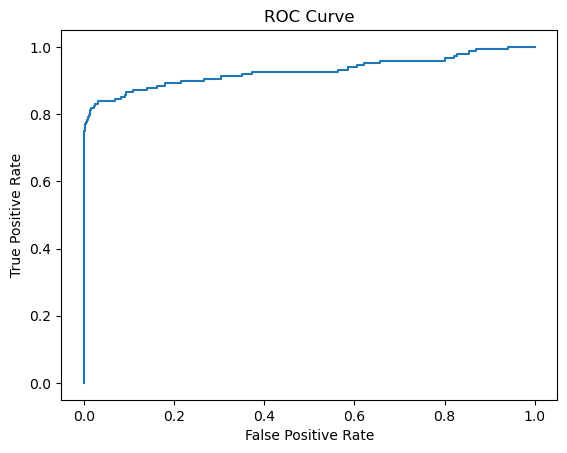

AUC: 0.9273659144812201


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

### Avaliação do modelo utilizando a Curva Precision-Recall

##### A Curva Precision-Recall demonstra que o modelo apresenta bom desempenho na identificação de fraudes, mantendo elevada precisão durante grande parte da curva. Entretanto, ao tentar aumentar a taxa de detecção das fraudes (recall), ocorre uma redução significativa da precisão, evidenciando o compromisso (trade-off) entre identificar mais fraudes e evitar falsos positivos. Esse comportamento é esperado em problemas de classificação desbalanceada, como detecção de fraudes financeiras.


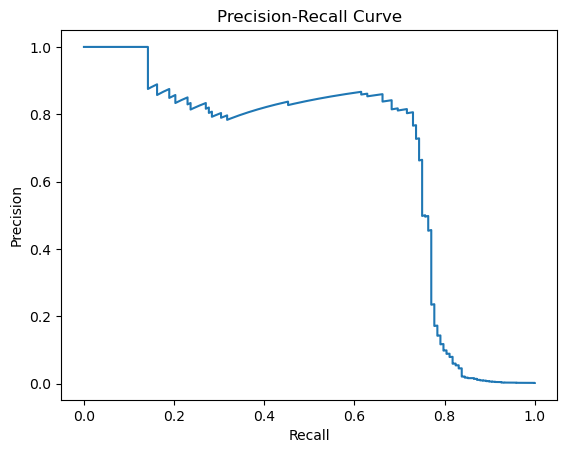

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#### Balanceamento de dados

##### Undersampling = Técnica de balanceamento que reduz a quantidade de exemplos da classe majoritária, selecionando uma amostra para igualar o número de registros da classe minoritária.

In [34]:
# Undersampling

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])


##### Oversampling = Técnica de balanceamento que aumenta a quantidade de exemplos da classe minoritária, gerando novas amostras sintéticas para equilibrar a distribuição das classes.

In [35]:
# Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

#### Resultado da avaliação do modelo Random Forest
###### O modelo Random Forest apresentou excelente desempenho geral, alcançando 100% de acurácia. Na detecção de fraudes (Class 1), obteve Precision de 0.84, Recall de 0.76 e F1-score de 0.79, indicando boa capacidade de identificar transações fraudulentas, com melhora na taxa de detecção em relação ao modelo anterior, embora ainda existam algumas fraudes não identificadas.

###### print(classification_report(y_test, y_pred))      # Logistic Regression

###### print(classification_report(y_test, y_pred_rf))   # Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



##### Pipeline = Estrutura do Scikit-Learn que organiza e executa, de forma sequencial, as etapas de pré-processamento e treinamento do modelo, garantindo que todas as transformações sejam aplicadas corretamente durante o treinamento e a predição.

In [39]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

##### Threshold = Limiar de decisão utilizado para converter as probabilidades previstas pelo modelo em classes. Se a probabilidade prevista for maior ou igual ao threshold, a amostra é classificada como positiva (1); caso contrário, é classificada como negativa (0).
###### Após reduzir o threshold para 0.3, o modelo apresentou Accuracy de 100%. Na Classe 1 (fraudes), obteve Precision de 0.82, Recall de 0.68 e F1-score de 0.75. A redução do limiar aumentou a capacidade de detectar fraudes em relação ao modelo original (Recall de 0.65 para 0.68), porém houve uma pequena redução na precisão (de 0.86 para 0.82), evidenciando o equilíbrio entre identificar mais fraudes e aumentar a ocorrência de falsos positivos.

In [40]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.68      0.75       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



##### Resultado da avaliação do modelo XGBoost
###### O modelo XGBoost apresentou o melhor desempenho entre os modelos avaliados, alcançando Accuracy de 100%. Na Classe 1 (fraudes), obteve Precision de 0.94, Recall de 0.78 e F1-score de 0.85, demonstrando excelente capacidade de identificar transações fraudulentas com baixa taxa de falsos positivos e maior taxa de detecção de fraudes em comparação aos modelos anteriores.

In [46]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,  # ajuda com desbalanceamento
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



#### Resultado final das abordagens realizadas

##### Logistic Regression: modelo base com bom desempenho inicial (F1-score = 0.74).
##### Pipeline (StandardScaler + Logistic Regression): organizou o fluxo de treinamento e manteve o desempenho da Regressão Logística (F1-score = 0.74).
##### Threshold (0.3): aumentou a capacidade de detectar fraudes (Recall), elevando o F1-score para 0.75.
##### Random Forest: melhorou significativamente a detecção de fraudes, alcançando F1-score de 0.79.
##### XGBoost: apresentou o melhor desempenho, com Precision = 0.94, Recall = 0.78 e F1-score = 0.85, sendo a abordagem mais eficaz para este conjunto de dados.

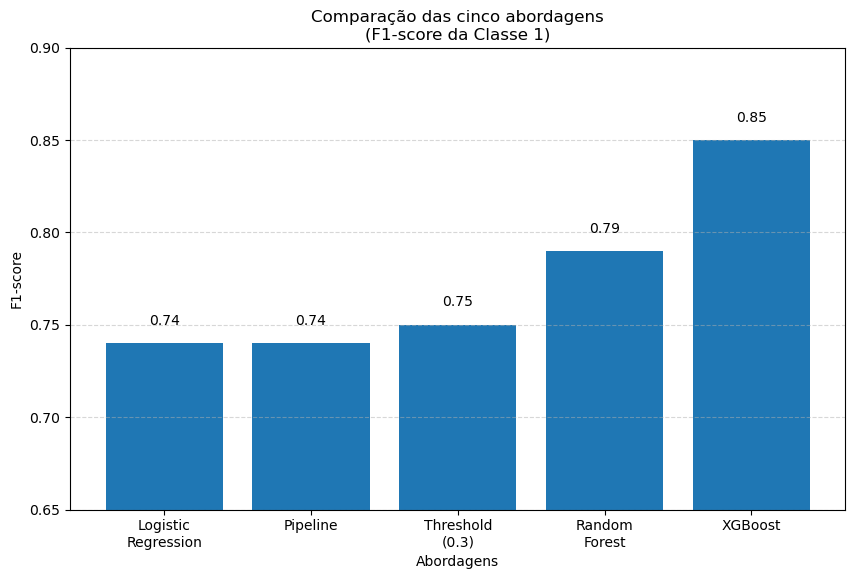

In [47]:
import matplotlib.pyplot as plt

# Abordagens avaliadas
abordagens = [
    "Logistic\nRegression",
    "Pipeline",
    "Threshold\n(0.3)",
    "Random\nForest",
    "XGBoost"
]

# F1-score da Classe 1 (Fraudes)
f1_scores = [0.74, 0.74, 0.75, 0.79, 0.85]

plt.figure(figsize=(10, 6))
bars = plt.bar(abordagens, f1_scores)

# Adiciona os valores sobre cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10
    )

plt.title("Comparação das cinco abordagens\n(F1-score da Classe 1)")
plt.xlabel("Abordagens")
plt.ylabel("F1-score")
plt.ylim(0.65, 0.90)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

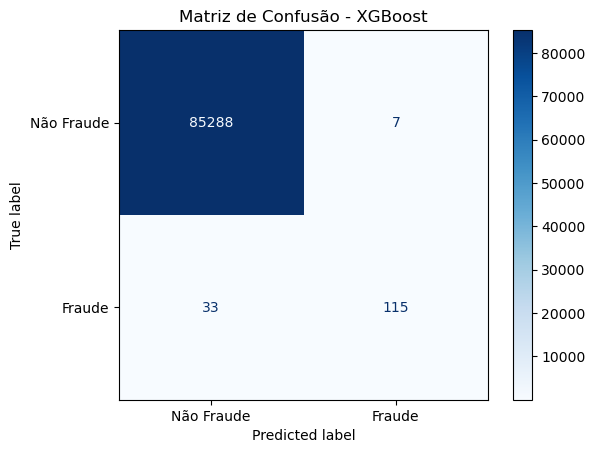

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Fraude", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - XGBoost")
plt.show()

In [49]:
import pandas as pd

# Tabela comparativa das abordagens
resultados = pd.DataFrame({
    "Abordagem": [
        "Logistic Regression",
        "Pipeline",
        "Threshold (0.3)",
        "Random Forest",
        "XGBoost"
    ],
    "Precision": [0.86, 0.86, 0.82, 0.84, 0.94],
    "Recall": [0.65, 0.65, 0.68, 0.76, 0.78],
    "F1-score": [0.74, 0.74, 0.75, 0.79, 0.85]
})

# Exibe a tabela
resultados

,Abordagem,Precision,Recall,F1-score
0,Logistic Regression,0.86,0.65,0.74
1,Pipeline,0.86,0.65,0.74
2,Threshold (0.3),0.82,0.68,0.75
3,Random Forest,0.84,0.76,0.79
4,XGBoost,0.94,0.78,0.85
